# Hierarchy example

This notebook provides a toy example for hierarchical reconciliation in a temporal hierarchy. It demonstrates the use of the `TemporalRidgeReconciliation` class for use with temporal hierarchies and `RidgeReconciliation` for general hierarchies.

**Reference**
Møller, J.K., Nystrup, P., and Madsen, H. (2024).  
*Likelihood-based inference in temporal hierarchies.*  
*International Journal of Forecasting*, **40**, 515–531.

First, import dependencies and the dataset

In [1]:
from py_online_forecast.hierarchies import *
import py_online_forecast.core as c
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from py_online_forecast.datasets import sample_hierarchical_data as data

The data is a pandas dataframe, containing observations and predictions for the hierarchy,

$$
Y_{A,t} = Y_{H,t-1} + Y_{H,t}
$$

For convenience, both the bottom level observations Y_{H,s} and the aggregated values Y_{A,s} are included. The data is structured using a pandas multiindex so that the i'th row has observations, $Y_{A,i}$, $Y_{H,i}$ and predictions $\hat{Y}_{A,i+2}$ and $\hat{Y}_{H,i+1}$, $\hat{Y}_{H,i+2}$.

In [2]:
data.head()

Variable       Y_A       Y_H  pred_Y_A  pred_Y_H          
Horizon          0         0         2         1         2
0         0.564940  0.056956  0.514225  0.052061  0.047586
1        -1.309807 -1.366763 -1.192225 -1.249289 -1.141912
2        -3.251866 -1.885103 -2.959944 -1.723078 -1.574979
3        -4.437113 -2.552010 -4.038790 -2.332664 -2.132171
4        -4.234289 -1.682279 -3.854174 -1.537687 -1.405522

To perform forecast reconciliation, we will use the purpose made `TemporalRidgeReconciliation` class. To use it, we first need to encode the structure of the hierarchy. We do so using the top level summation matrix,

In [3]:
S = np.array([[1,1],[1,0],[0,1]])
S_top = S[[0]]

And a "backshift" operator, indicating how the bottom level observations, should be lagged to form the bottom level of the hierarchy. In this case, we assume we are given $Y_{H,s}$ and thus need to form the vector $(Y_{H,s-1}, Y_{H,s})$. The backshift operator is then specified as,

In [4]:
B = [1, 0] # [Y_{H,t-1}, Y_{H,t-0}]

We can then construct the reconciliation model as,

In [5]:
temporal_reconciler = TemporalRidgeReconciliation(
    S_top,                        # Top level summation matrix
    B,                            # Backshifts for bottom level in temporal hierarchy
    full_cov=True,                # Argument passed to `RRR` for estimating covariance or just variances
    skip_duplicates=True,         # Whether to skip duplicate data updates
    opt_shrink=False,             # Whether to use SRRR or RRR for estimation
    full_hierarchy_cov=False,     # Whether to reconstruct the full hierarchy covariance matrix or just the variances
)

> **Note:** by default, the reconciliation horizon is assumed to be $\max(B) + 1$. This can be changed by explicitly setting the `horizon` argument.

To ensure the output matches the input format (i.e. the `ForecastFormat`), we need to specify a formatter for the reconciler. If we do not specify a formatter, the reconciler will not track the sources of the data and the output will be a numpy array

In [6]:
from py_online_forecast.forecast_tools import ForecastFormat
temporal_reconciler.set_format(ForecastFormat)

We then extract data for reconciliation and fit the model,

In [7]:
# Extract data
Y_hat = data[["pred_Y_A","pred_Y_H"]]
Y_bot = data[["Y_H"]]

# Fit the model
res = temporal_reconciler.fit(Y_bot = Y_bot, Y_hat = Y_hat)

The result is a `dict` with "mean" and "cov" as keys and pandas dataframes as values,

In [8]:
res["mean"].head()

Variable  pred_Y_A  pred_Y_H          
Horizon          2         1         2
0              NaN       NaN       NaN
1              NaN       NaN       NaN
2              NaN       NaN       NaN
3        -5.191829 -2.558594 -2.633235
4        -1.388755 -1.054605 -0.334151

In [9]:
res["cov"].head(9)

Variable  pred_Y_A  pred_Y_H          
Horizon          2         1         2
0              NaN       NaN       NaN
1              NaN       NaN       NaN
2              NaN       NaN       NaN
3              NaN       NaN       NaN
4              NaN       NaN       NaN
5              NaN       NaN       NaN
6              NaN       NaN       NaN
7         0.143827  0.026645  0.046661
8         0.255483  0.047330  0.082886

We can also perform the updates incrementally to emulate an online setting,

In [11]:
# First, reset the state of the reconciler (i.e. clear data and paramter estimates)
temporal_reconciler.reset_state()

# Then, loop over rows in the data and update the reconciler one step at a time
mean = []
cov  = []
for t in range(len(Y_bot)):
    Y_bot_t = Y_bot.iloc[[t]]
    Y_hat_t = Y_hat.iloc[[t]]
    rec_t = temporal_reconciler.update(Y_bot_t, Y_hat_t)
    mean.append(rec_t["mean"])
    cov.append(rec_t["cov"])

mean = pd.concat(mean)
cov = pd.concat(cov)

In [12]:
mean.head()

Variable  pred_Y_A  pred_Y_H          
Horizon          2         1         2
0              NaN       NaN       NaN
1              NaN       NaN       NaN
2              NaN       NaN       NaN
3        -5.191829 -2.558594 -2.633235
4        -1.388755 -1.054605 -0.334151

In [13]:
cov.head(9)

Variable  pred_Y_A  pred_Y_H          
Horizon          2         1         2
0              NaN       NaN       NaN
1              NaN       NaN       NaN
2              NaN       NaN       NaN
3              NaN       NaN       NaN
4              NaN       NaN       NaN
5              NaN       NaN       NaN
6              NaN       NaN       NaN
7         0.143827  0.026645  0.046661
8         0.255483  0.047330  0.082886

Behind the scenes `TemporalRidgeReconciliation` is a lightweight wrapper around `RidgeReconciliation`, that normalizes inputs to conform to a general hierarchy. To illustrate the use of the latter class, we can do the normalization manually,

In [14]:
# Create bottom level of hierarchy using the BackShift class
Y_bot_full = p.BackShift(B, skip_duplicates=True)(Y_bot)
Y_bot_full

array([[        nan,         nan],
       [ 0.05695592, -1.3667628 ],
       [        nan,         nan],
       ...,
       [-1.18745718, -0.9006303 ],
       [        nan,         nan],
       [-0.6741683 , -1.13386409]])

Then construct and fit the reconciliation model

In [16]:
reconciler = RidgeReconciliation(
    S_top, horizon=2, opt_shrink=False)
reconciler.set_format(ForecastFormat)
res = reconciler.fit(Y_bot_full, Y_hat)

In [17]:
res["mean"].head()

Variable  pred_Y_A  pred_Y_H          
Horizon          2         1         2
0              NaN       NaN       NaN
1              NaN       NaN       NaN
2              NaN       NaN       NaN
3        -5.191829 -2.558594 -2.633235
4        -1.388755 -1.054605 -0.334151

Note, either of the reconciliation classes can use `Source` instances as inputs. In fact `TemporalRidgeReconciliation` is more or less implemented as,

In [18]:
# Construct sources for inputs
Z_bot = c.Source("Z_bot")
Y_pred = c.Source("Y_pred")

# Backshift observations
Y_bot_full = p.BackShift(B, skip_duplicates=True, data = Z_bot)

# Construct reconciler
reconciler = RidgeReconciliation(
    S_top, horizon=2, opt_shrink=False, Y_bot = Y_bot_full, Y_hat = Y_pred
    )

# Apply formatting
reconciler.set_format(ForecastFormat)

# Call using the generic transform interface
res = reconciler({Z_bot: Y_bot, Y_pred: Y_hat})

We can plot the forecasts,

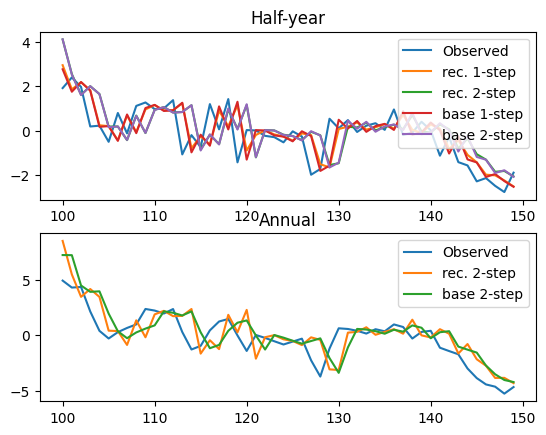

In [19]:
Y_hat_rec = res["mean"]

Y_top = data[["Y_A"]]

n_start = 100
n_plot = 50
fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.set_title("Half-year")
Y_bot.iloc[n_start:n_start + n_plot].plot(ax=ax1)
Y_hat_rec[["pred_Y_H"]].fc.lag().iloc[n_start:n_start + n_plot].plot(ax=ax1)
Y_hat[["pred_Y_H"]].fc.lag().iloc[n_start:n_start + n_plot].plot(ax=ax1)
ax1.legend(["Observed", "rec. 1-step", "rec. 2-step", "base 1-step", "base 2-step"])

ax2.set_title("Annual")
Y_top.iloc[n_start:n_start + n_plot].plot(ax=ax2)
Y_hat_rec[["pred_Y_A"]].fc.lag().iloc[n_start:n_start + n_plot].plot(ax=ax2)
Y_hat[["pred_Y_A"]].fc.lag().iloc[n_start:n_start + n_plot].plot(ax=ax2)
ax2.legend(["Observed", "rec. 2-step", "base 2-step"])
plt.show()

And a histogram of the residuals,

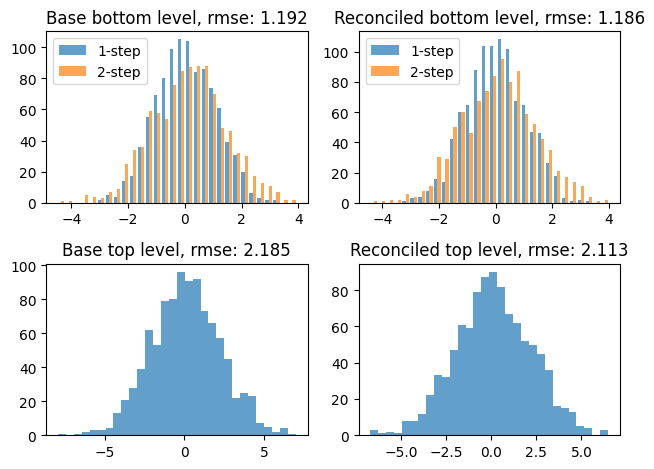

In [20]:
#%% Get residuals
resid_base_bot = -Y_hat[["pred_Y_H"]].fc.lag().sub(Y_bot.to_numpy(), axis = 0)
resid_base_top = -Y_hat[["pred_Y_A"]].fc.lag().sub(Y_top.to_numpy())
resid_rec_bot = -Y_hat_rec[["pred_Y_H"]].fc.lag().sub(Y_bot.to_numpy(), axis = 0)
resid_rec_top = -Y_hat_rec[["pred_Y_A"]].fc.lag().sub(Y_top.to_numpy())

rmse_base_bot = p.rmse(resid_base_bot)
rmse_base_top = p.rmse(resid_base_top)
rmse_rec_bot = p.rmse(resid_rec_bot)
rmse_rec_top = p.rmse(resid_rec_top)

#%% Make histograms of residuals
fig, axes = plt.subplots(2, 2)
axes[0, 0].hist(resid_base_bot.dropna(), bins=30, alpha=0.7)
axes[0, 0].legend(["1-step", "2-step"])
axes[0, 0].set_title(f"Base bottom level, rmse: {rmse_base_bot:.3f}")
axes[0, 1].hist(resid_rec_bot.dropna(), bins=30, alpha=0.7)
axes[0, 1].legend(["1-step", "2-step"])
axes[0, 1].set_title(f"Reconciled bottom level, rmse: {rmse_rec_bot:.3f}")
axes[1, 0].hist(resid_base_top.dropna(), bins=30, alpha=0.7)
axes[1, 0].set_title(f"Base top level, rmse: {rmse_base_top:.3f}")
axes[1, 1].hist(resid_rec_top.dropna(), bins=30, alpha=0.7)
axes[1, 1].set_title(f"Reconciled top level, rmse: {rmse_rec_top:.3f}")
plt.tight_layout()
plt.show()